# Chapter 3 - Data Transformation


In [1]:
# Requisitos Previos
library(tidyverse)

install.packages("nycflights13")
library(nycflights13)
flights

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


In [ ]:
glimpse(flights)

Rows: 336,776
Columns: 19
$ year           <int> 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2…
$ month          <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ day            <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ dep_time       <int> 517, 533, 542, 544, 554, 554, 555, 557, 557, 558, 558, …
$ sched_dep_time <int> 515, 529, 540, 545, 600, 558, 600, 600, 600, 600, 600, …
$ dep_delay      <dbl> 2, 4, 2, -1, -6, -4, -5, -3, -3, -2, -2, -2, -2, -2, -1…
$ arr_time       <int> 830, 850, 923, 1004, 812, 740, 913, 709, 838, 753, 849,…
$ sched_arr_time <int> 819, 830, 850, 1022, 837, 728, 854, 723, 846, 745, 851,…
$ arr_delay      <dbl> 11, 20, 33, -18, -25, 12, 19, -14, -8, 8, -2, -3, 7, -1…
$ carrier        <chr> "UA", "UA", "AA", "B6", "DL", "UA", "B6", "EV", "B6", "…
$ flight         <int> 1545, 1714, 1141, 725, 461, 1696, 507, 5708, 79, 301, 4…
$ tailnum        <chr> "N14228", "N24211", "N619AA", "N804JB", "N668DN", "N394…
$ origin      

## dplyr Básico

In [ ]:
flights |>
  filter(dest == 'IAH') |>
  group_by(year, month, day) |>
  summarize(
    arr_delay = mean(arr_delay, na.rm = TRUE)
  )

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year, month, and day.
ℹ Output is grouped by year and month.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, month, day))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


year,month,day,arr_delay
<int>,<int>,<int>,<dbl>
2013,1,1,17.850000
2013,1,2,7.000000
2013,1,3,18.315789
2013,1,4,-3.200000
2013,1,5,20.230769
2013,1,6,9.277778
2013,1,7,-7.736842
2013,1,8,7.789474
2013,1,9,18.055556


In [ ]:
#Filas
#Los verbos más importantes que operan sobre las filas de un conjunto de datos son filter()
# que cambia  el orden de las filas sin cambiar su orden.
# arrange() que cambia el orden de las filas sin cambiar las que están presentes.
# distinct() que encuentra filas con valores únicos y puede modificar opcionalmente las columnas.

## Filtrar

In [ ]:
# Encontremos todos los vuelos que salieron con más de 120 minutos de retraso
flights |>
  filter(dep_delay > 120)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,848,1835,853,1001,1950,851,MQ,3944,N942MQ,JFK,BWI,41,184,18,35,2013-01-01 18:00:00
2013,1,1,957,733,144,1056,853,123,UA,856,N534UA,EWR,BOS,37,200,7,33,2013-01-01 07:00:00
2013,1,1,1114,900,134,1447,1222,145,UA,1086,N76502,LGA,IAH,248,1416,9,0,2013-01-01 09:00:00
2013,1,1,1540,1338,122,2020,1825,115,B6,705,N570JB,JFK,SJU,193,1598,13,38,2013-01-01 13:00:00
2013,1,1,1815,1325,290,2120,1542,338,EV,4417,N17185,EWR,OMA,213,1134,13,25,2013-01-01 13:00:00
2013,1,1,1842,1422,260,1958,1535,263,EV,4633,N18120,EWR,BTV,46,266,14,22,2013-01-01 14:00:00
2013,1,1,1856,1645,131,2212,2005,127,AA,181,N323AA,JFK,LAX,336,2475,16,45,2013-01-01 16:00:00
2013,1,1,1934,1725,129,2126,1855,151,MQ,4255,N909MQ,JFK,BNA,154,765,17,25,2013-01-01 17:00:00
2013,1,1,1938,1703,155,2109,1823,166,EV,4300,N18557,EWR,RIC,68,277,17,3,2013-01-01 17:00:00


In [ ]:
#Vuelos que partieron el 1 de Enero
flights |>
  filter(month == 1 & day == 1)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


In [ ]:
# Seleccionar mes 1 y 2
flights |>
filter(month == 1 | month == 2)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


In [ ]:
#Uso de %in%
flights |>
  filter(month %in% c(1,2))

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


In [ ]:
#Guardado
jan1 <- flights |>
  filter(month == 1 & day == 1)

# Ordenar()

In [ ]:
# arrange() cambia el orden de las filas en función del valor de las columnas.
flights |>
  arrange(year, month, day, dep_time)

flights |>
  arrange(desc(dep_delay))

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,9,641,900,1301,1242,1530,1272,HA,51,N384HA,JFK,HNL,640,4983,9,0,2013-01-09 09:00:00
2013,6,15,1432,1935,1137,1607,2120,1127,MQ,3535,N504MQ,JFK,CMH,74,483,19,35,2013-06-15 19:00:00
2013,1,10,1121,1635,1126,1239,1810,1109,MQ,3695,N517MQ,EWR,ORD,111,719,16,35,2013-01-10 16:00:00
2013,9,20,1139,1845,1014,1457,2210,1007,AA,177,N338AA,JFK,SFO,354,2586,18,45,2013-09-20 18:00:00
2013,7,22,845,1600,1005,1044,1815,989,MQ,3075,N665MQ,JFK,CVG,96,589,16,0,2013-07-22 16:00:00
2013,4,10,1100,1900,960,1342,2211,931,DL,2391,N959DL,JFK,TPA,139,1005,19,0,2013-04-10 19:00:00
2013,3,17,2321,810,911,135,1020,915,DL,2119,N927DA,LGA,MSP,167,1020,8,10,2013-03-17 08:00:00
2013,6,27,959,1900,899,1236,2226,850,DL,2007,N3762Y,JFK,PDX,313,2454,19,0,2013-06-27 19:00:00
2013,7,22,2257,759,898,121,1026,895,DL,2047,N6716C,LGA,ATL,109,762,7,59,2013-07-22 07:00:00


# Distinto()

In [ ]:
# distinct() encuentra todas las filas únicas de un conjunto de datos.
# Remove duplicate row, if any
flights |>
  distinct()

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


In [ ]:
# Find all unique origin and destination pairs
flights |>
  distinct(origin, dest)

origin,dest
<chr>,<chr>
EWR,IAH
LGA,IAH
JFK,MIA
JFK,BQN
LGA,ATL
EWR,ORD
EWR,FLL
LGA,IAD
JFK,MCO


In [ ]:
# Si queremos mantener las demás columnas, usamos .keep_all = TRUE
flights |>
  distinct(origin, dest, .keep_all = TRUE)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


In [ ]:
# Para contar las ocurrencias, ocupamos count() y con el argumento sort = TRUE se pueden ordenar descendentemente
flights |>
  count(origin, dest, sort = TRUE)

origin,dest,n
<chr>,<chr>,<int>
JFK,LAX,11262
LGA,ATL,10263
LGA,ORD,8857
JFK,SFO,8204
LGA,CLT,6168
EWR,ORD,6100
JFK,BOS,5898
LGA,MIA,5781
JFK,MCO,5464


# Ejercicios

In [ ]:
#1. En una única canalización para cada condición, encuentra todos los vuelos que cumplan la condición:
# Tuvo un retraso de llegada de dos o más horas.
flights |>
  filter(arr_delay >= 120)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,811,630,101,1047,830,137,MQ,4576,N531MQ,LGA,CLT,118,544,6,30,2013-01-01 06:00:00
2013,1,1,848,1835,853,1001,1950,851,MQ,3944,N942MQ,JFK,BWI,41,184,18,35,2013-01-01 18:00:00
2013,1,1,957,733,144,1056,853,123,UA,856,N534UA,EWR,BOS,37,200,7,33,2013-01-01 07:00:00
2013,1,1,1114,900,134,1447,1222,145,UA,1086,N76502,LGA,IAH,248,1416,9,0,2013-01-01 09:00:00
2013,1,1,1505,1310,115,1638,1431,127,EV,4497,N17984,EWR,RIC,63,277,13,10,2013-01-01 13:00:00
2013,1,1,1525,1340,105,1831,1626,125,B6,525,N231JB,EWR,MCO,152,937,13,40,2013-01-01 13:00:00
2013,1,1,1549,1445,64,1912,1656,136,EV,4181,N21197,EWR,MCI,234,1092,14,45,2013-01-01 14:00:00
2013,1,1,1558,1359,119,1718,1515,123,EV,5712,N826AS,JFK,IAD,53,228,13,59,2013-01-01 13:00:00
2013,1,1,1732,1630,62,2028,1825,123,EV,4092,N16911,EWR,DAY,119,533,16,30,2013-01-01 16:00:00


In [ ]:
# Voló a Houston (IAH o HOU)
flights |>
  filter(dest %in% c('IAH','HOU'))

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,623,627,-4,933,932,1,UA,496,N459UA,LGA,IAH,229,1416,6,27,2013-01-01 06:00:00
2013,1,1,728,732,-4,1041,1038,3,UA,473,N488UA,LGA,IAH,238,1416,7,32,2013-01-01 07:00:00
2013,1,1,739,739,0,1104,1038,26,UA,1479,N37408,EWR,IAH,249,1400,7,39,2013-01-01 07:00:00
2013,1,1,908,908,0,1228,1219,9,UA,1220,N12216,EWR,IAH,233,1400,9,8,2013-01-01 09:00:00
2013,1,1,1028,1026,2,1350,1339,11,UA,1004,N76508,LGA,IAH,237,1416,10,26,2013-01-01 10:00:00
2013,1,1,1044,1045,-1,1352,1351,1,UA,455,N667UA,EWR,IAH,229,1400,10,45,2013-01-01 10:00:00
2013,1,1,1114,900,134,1447,1222,145,UA,1086,N76502,LGA,IAH,248,1416,9,0,2013-01-01 09:00:00


In [ ]:
# Salida en verano(julio, agosto y septiembre)
flights |>
  filter(month %in% c(7,8,9))

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,7,1,1,2029,212,236,2359,157,B6,915,N653JB,JFK,SFO,315,2586,20,29,2013-07-01 20:00:00
2013,7,1,2,2359,3,344,344,0,B6,1503,N805JB,JFK,SJU,200,1598,23,59,2013-07-01 23:00:00
2013,7,1,29,2245,104,151,1,110,B6,234,N348JB,JFK,BTV,66,266,22,45,2013-07-01 22:00:00
2013,7,1,43,2130,193,322,14,188,B6,1371,N794JB,LGA,FLL,143,1076,21,30,2013-07-01 21:00:00
2013,7,1,44,2150,174,300,100,120,AA,185,N324AA,JFK,LAX,297,2475,21,50,2013-07-01 21:00:00
2013,7,1,46,2051,235,304,2358,186,B6,165,N640JB,JFK,PDX,304,2454,20,51,2013-07-01 20:00:00
2013,7,1,48,2001,287,308,2305,243,VX,415,N627VA,JFK,LAX,298,2475,20,1,2013-07-01 20:00:00
2013,7,1,58,2155,183,335,43,172,B6,425,N535JB,JFK,TPA,140,1005,21,55,2013-07-01 21:00:00
2013,7,1,100,2146,194,327,30,177,B6,1183,N531JB,JFK,MCO,126,944,21,46,2013-07-01 21:00:00


In [ ]:
# Llegó más de dos horas tarde, pero no se fue tarde.
flights |>
  filter(dep_delay <= 0 & arr_delay > 120)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,27,1419,1420,-1,1754,1550,124,MQ,3728,N1EAMQ,EWR,ORD,135,719,14,20,2013-01-27 14:00:00
2013,10,7,1350,1350,0,1736,1526,130,EV,5181,N611QX,LGA,MSN,117,812,13,50,2013-10-07 13:00:00
2013,10,7,1357,1359,-2,1858,1654,124,AA,1151,N3CMAA,LGA,DFW,192,1389,13,59,2013-10-07 13:00:00
2013,10,16,657,700,-3,1258,1056,122,B6,3,N703JB,JFK,SJU,225,1598,7,0,2013-10-16 07:00:00
2013,11,1,658,700,-2,1329,1015,194,VX,399,N629VA,JFK,LAX,336,2475,7,0,2013-11-01 07:00:00
2013,3,18,1844,1847,-3,39,2219,140,UA,389,N560UA,JFK,SFO,386,2586,18,47,2013-03-18 18:00:00
2013,4,17,1635,1640,-5,2049,1845,124,MQ,4540,N721MQ,LGA,DTW,130,502,16,40,2013-04-17 16:00:00
2013,4,18,558,600,-2,1149,850,179,AA,707,N3EXAA,LGA,DFW,234,1389,6,0,2013-04-18 06:00:00
2013,4,18,655,700,-5,1213,950,143,AA,2083,N565AA,EWR,DFW,230,1372,7,0,2013-04-18 07:00:00


In [ ]:
# Se retrasaron al menos una hora, pero recuperaron más de 30 minutos de vuelo.
flights |>
  filter(dep_delay >= 60 & (dep_delay -arr_delay) > 30)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,2205,1720,285,46,2040,246,AA,1999,N5DNAA,EWR,MIA,146,1085,17,20,2013-01-01 17:00:00
2013,1,1,2326,2130,116,131,18,73,B6,199,N594JB,JFK,LAS,290,2248,21,30,2013-01-01 21:00:00
2013,1,3,1503,1221,162,1803,1555,128,UA,551,N835UA,EWR,SFO,320,2565,12,21,2013-01-03 12:00:00
2013,1,3,1839,1700,99,2056,1950,66,AA,575,N631AA,JFK,EGE,239,1747,17,0,2013-01-03 17:00:00
2013,1,3,1850,1745,65,2148,2120,28,AA,177,N332AA,JFK,SFO,314,2586,17,45,2013-01-03 17:00:00
2013,1,3,1941,1759,102,2246,2139,67,UA,979,N402UA,EWR,PHX,274,2133,17,59,2013-01-03 17:00:00
2013,1,3,1950,1845,65,2228,2227,1,B6,91,N636JB,JFK,OAK,319,2576,18,45,2013-01-03 18:00:00
2013,1,3,2015,1915,60,2135,2111,24,9E,3525,N903XJ,JFK,ORD,110,740,19,15,2013-01-03 19:00:00
2013,1,3,2257,2000,177,45,2224,141,9E,3439,N931XJ,JFK,CVG,90,589,20,0,2013-01-03 20:00:00


In [ ]:
#2. Ordena flights para encontrar los vuelos con mayor retraso en la salida.
flights |>
  arrange(desc(arr_delay))
#Encuentra los vuelos que salieron más temprano por la mañana
flights |>
  arrange(dep_time)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,9,641,900,1301,1242,1530,1272,HA,51,N384HA,JFK,HNL,640,4983,9,0,2013-01-09 09:00:00
2013,6,15,1432,1935,1137,1607,2120,1127,MQ,3535,N504MQ,JFK,CMH,74,483,19,35,2013-06-15 19:00:00
2013,1,10,1121,1635,1126,1239,1810,1109,MQ,3695,N517MQ,EWR,ORD,111,719,16,35,2013-01-10 16:00:00
2013,9,20,1139,1845,1014,1457,2210,1007,AA,177,N338AA,JFK,SFO,354,2586,18,45,2013-09-20 18:00:00
2013,7,22,845,1600,1005,1044,1815,989,MQ,3075,N665MQ,JFK,CVG,96,589,16,0,2013-07-22 16:00:00
2013,4,10,1100,1900,960,1342,2211,931,DL,2391,N959DL,JFK,TPA,139,1005,19,0,2013-04-10 19:00:00
2013,3,17,2321,810,911,135,1020,915,DL,2119,N927DA,LGA,MSP,167,1020,8,10,2013-03-17 08:00:00
2013,7,22,2257,759,898,121,1026,895,DL,2047,N6716C,LGA,ATL,109,762,7,59,2013-07-22 07:00:00
2013,12,5,756,1700,896,1058,2020,878,AA,172,N5DMAA,EWR,MIA,149,1085,17,0,2013-12-05 17:00:00


year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,13,1,2249,72,108,2357,71,B6,22,N206JB,JFK,SYR,41,209,22,49,2013-01-13 22:00:00
2013,1,31,1,2100,181,124,2225,179,WN,530,N550WN,LGA,MDW,127,725,21,0,2013-01-31 21:00:00
2013,11,13,1,2359,2,442,440,2,B6,1503,N627JB,JFK,SJU,194,1598,23,59,2013-11-13 23:00:00
2013,12,16,1,2359,2,447,437,10,B6,839,N607JB,JFK,BQN,202,1576,23,59,2013-12-16 23:00:00
2013,12,20,1,2359,2,430,440,-10,B6,1503,N608JB,JFK,SJU,182,1598,23,59,2013-12-20 23:00:00
2013,12,26,1,2359,2,437,440,-3,B6,1503,N527JB,JFK,SJU,197,1598,23,59,2013-12-26 23:00:00
2013,12,30,1,2359,2,441,437,4,B6,839,N508JB,JFK,BQN,198,1576,23,59,2013-12-30 23:00:00
2013,2,11,1,2100,181,111,2225,166,WN,530,N231WN,LGA,MDW,117,725,21,0,2013-02-11 21:00:00
2013,2,24,1,2245,76,121,2354,87,B6,608,N216JB,JFK,PWM,56,273,22,45,2013-02-24 22:00:00


In [ ]:
#3. Ordena flights para encontrar los vuelos más rápidos.
flights |>
  arrange(desc(distance / air_time))

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,5,25,1709,1700,9,1923,1937,-14,DL,1499,N666DN,LGA,ATL,65,762,17,0,2013-05-25 17:00:00
2013,7,2,1558,1513,45,1745,1719,26,EV,4667,N17196,EWR,MSP,93,1008,15,13,2013-07-02 15:00:00
2013,5,13,2040,2025,15,2225,2226,-1,EV,4292,N14568,EWR,GSP,55,594,20,25,2013-05-13 20:00:00
2013,3,23,1914,1910,4,2045,2043,2,EV,3805,N12567,EWR,BNA,70,748,19,10,2013-03-23 19:00:00
2013,1,12,1559,1600,-1,1849,1917,-28,DL,1902,N956DL,LGA,PBI,105,1035,16,0,2013-01-12 16:00:00
2013,11,17,650,655,-5,1059,1150,-51,DL,315,N3768,JFK,SJU,170,1598,6,55,2013-11-17 06:00:00
2013,2,21,2355,2358,-3,412,438,-26,B6,707,N779JB,JFK,SJU,172,1598,23,58,2013-02-21 23:00:00
2013,11,17,759,800,-1,1212,1255,-43,AA,936,N5FFAA,JFK,STT,175,1623,8,0,2013-11-17 08:00:00
2013,11,16,2003,1925,38,17,36,-19,DL,347,N3773D,JFK,SJU,173,1598,19,25,2013-11-16 19:00:00


In [ ]:
#4. ¿Hubo un vuelo todos los días de 2023?
flights |>
  distinct(month, day)

month,day
<int>,<int>
1,1
1,2
1,3
1,4
1,5
1,6
1,7
1,8
1,9


In [ ]:
#5 ¿Qué vuelos recorrieron la mayor distancia?
flights |>
  arrange(desc(distance))

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,857,900,-3,1516,1530,-14,HA,51,N380HA,JFK,HNL,659,4983,9,0,2013-01-01 09:00:00
2013,1,2,909,900,9,1525,1530,-5,HA,51,N380HA,JFK,HNL,638,4983,9,0,2013-01-02 09:00:00
2013,1,3,914,900,14,1504,1530,-26,HA,51,N380HA,JFK,HNL,616,4983,9,0,2013-01-03 09:00:00
2013,1,4,900,900,0,1516,1530,-14,HA,51,N384HA,JFK,HNL,639,4983,9,0,2013-01-04 09:00:00
2013,1,5,858,900,-2,1519,1530,-11,HA,51,N381HA,JFK,HNL,635,4983,9,0,2013-01-05 09:00:00
2013,1,6,1019,900,79,1558,1530,28,HA,51,N385HA,JFK,HNL,611,4983,9,0,2013-01-06 09:00:00
2013,1,7,1042,900,102,1620,1530,50,HA,51,N385HA,JFK,HNL,612,4983,9,0,2013-01-07 09:00:00
2013,1,8,901,900,1,1504,1530,-26,HA,51,N389HA,JFK,HNL,645,4983,9,0,2013-01-08 09:00:00
2013,1,9,641,900,1301,1242,1530,1272,HA,51,N384HA,JFK,HNL,640,4983,9,0,2013-01-09 09:00:00


In [ ]:
#¿Cuáles recorrieron la menor distancia?
flights |>
  arrange(distance)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,7,27,NA,106,NA,NA,245,NA,US,1632,NA,EWR,LGA,NA,17,1,6,2013-07-27 01:00:00
2013,1,3,2127,2129,-2,2222,2224,-2,EV,3833,N13989,EWR,PHL,30,80,21,29,2013-01-03 21:00:00
2013,1,4,1240,1200,40,1333,1306,27,EV,4193,N14972,EWR,PHL,30,80,12,0,2013-01-04 12:00:00
2013,1,4,1829,1615,134,1937,1721,136,EV,4502,N15983,EWR,PHL,28,80,16,15,2013-01-04 16:00:00
2013,1,4,2128,2129,-1,2218,2224,-6,EV,4645,N27962,EWR,PHL,32,80,21,29,2013-01-04 21:00:00
2013,1,5,1155,1200,-5,1241,1306,-25,EV,4193,N14902,EWR,PHL,29,80,12,0,2013-01-05 12:00:00
2013,1,6,2125,2129,-4,2224,2224,0,EV,4619,N22909,EWR,PHL,22,80,21,29,2013-01-06 21:00:00
2013,1,7,2124,2129,-5,2212,2224,-12,EV,4619,N33182,EWR,PHL,25,80,21,29,2013-01-07 21:00:00
2013,1,8,2127,2130,-3,2304,2225,39,EV,4619,N11194,EWR,PHL,30,80,21,30,2013-01-08 21:00:00


In [ ]:
#6 ¿Importa el orden filter() y arrange() si utilizas ambos?
#¿Por qué /por qué no? Piensa en los resultados y en el trabajo que tendrían que hacer las funciones
# El resultado final suele ser el mismo, pero la eficiencia (el trabajo que hace la computadora) cambia drásticamente.
# Ordenar (arrange) es una de las tareas que más recursos consume (computacionalmente hablando). Filtrar (filter) es muy "barato". Por lo tanto, siempre quieres ordenar la menor cantidad de datos posible.

# Columnas

Hay 4 argumentos importantes que afecta a las columnas sin modificar las filas.

*   mutate()
*   select()
*   rename()
*   relocate()


## Mutate()

In [ ]:
# La función mutar añade nuevas columnas que se calculan en base a las columnas existentes.
flights |>
  mutate(
  gain = dep_delay - arr_delay,
  speed = distance / air_time * 60
  )

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,⋯,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,gain,speed
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<dbl>,<dbl>
2013,1,1,517,515,2,830,819,11,UA,⋯,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00,-9,370.0441
2013,1,1,533,529,4,850,830,20,UA,⋯,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00,-16,374.2731
2013,1,1,542,540,2,923,850,33,AA,⋯,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00,-31,408.3750
2013,1,1,544,545,-1,1004,1022,-18,B6,⋯,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00,17,516.7213
2013,1,1,554,600,-6,812,837,-25,DL,⋯,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00,19,394.1379
2013,1,1,554,558,-4,740,728,12,UA,⋯,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00,-16,287.6000
2013,1,1,555,600,-5,913,854,19,B6,⋯,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00,-24,404.4304
2013,1,1,557,600,-3,709,723,-14,EV,⋯,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00,11,259.2453
2013,1,1,557,600,-3,838,846,-8,B6,⋯,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00,5,404.5714


In [ ]:
# Por defecto, mutate() añade las nuevas columnas al lado derecho del conjunto de datos, lo que puede dificultar su visualización.
# Para arreglar esta situación se puede utilizar .before para añadir los argumentos en el lado izquierdo.
flights |>
  mutate(
  gain = dep_delay - arr_delay,
  speed = distance / air_time * 60,
  .before = 1
  )

gain,speed,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,⋯,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,⋯,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
-9,370.0441,2013,1,1,517,515,2,830,819,⋯,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
-16,374.2731,2013,1,1,533,529,4,850,830,⋯,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
-31,408.3750,2013,1,1,542,540,2,923,850,⋯,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
17,516.7213,2013,1,1,544,545,-1,1004,1022,⋯,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
19,394.1379,2013,1,1,554,600,-6,812,837,⋯,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
-16,287.6000,2013,1,1,554,558,-4,740,728,⋯,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
-24,404.4304,2013,1,1,555,600,-5,913,854,⋯,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
11,259.2453,2013,1,1,557,600,-3,709,723,⋯,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
5,404.5714,2013,1,1,557,600,-3,838,846,⋯,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


In [ ]:
# Se puede ocupar .after para añadir las columnas después de algun argumento. En este caso, despues del argumento dia
flights |>
  mutate(
  gain = dep_delay - arr_delay,
  speed = distance / air_time * 60,
  .after = day
  )

year,month,day,gain,speed,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,⋯,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,⋯,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,-9,370.0441,517,515,2,830,819,⋯,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,-16,374.2731,533,529,4,850,830,⋯,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,-31,408.3750,542,540,2,923,850,⋯,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,17,516.7213,544,545,-1,1004,1022,⋯,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,19,394.1379,554,600,-6,812,837,⋯,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,-16,287.6000,554,558,-4,740,728,⋯,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,-24,404.4304,555,600,-5,913,854,⋯,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,11,259.2453,557,600,-3,709,723,⋯,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,5,404.5714,557,600,-3,838,846,⋯,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


In [ ]:
# Tambien se pueden controlar que variables se conservan con el argumento .keep.# 'used' es un argumento util para consevar las columnas que intervinieron con mutate()
delay_gain <- flights |>
  mutate(
  gain = dep_delay - arr_delay,
  speed = distance / air_time * 60,
  gain_per_hour = gain / hour,
  .keep = 'used'
  )
  delay_gain

dep_delay,arr_delay,air_time,distance,hour,gain,speed,gain_per_hour
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,11,227,1400,5,-9,370.0441,-1.8000000
4,20,227,1416,5,-16,374.2731,-3.2000000
2,33,160,1089,5,-31,408.3750,-6.2000000
-1,-18,183,1576,5,17,516.7213,3.4000000
-6,-25,116,762,6,19,394.1379,3.1666667
-4,12,150,719,5,-16,287.6000,-3.2000000
-5,19,158,1065,6,-24,404.4304,-4.0000000
-3,-14,53,229,6,11,259.2453,1.8333333
-3,-8,140,944,6,5,404.5714,0.8333333


## Select()

In [ ]:
# select() permite ampliar rapidamente un subconjunto útil utilizando operaciones basadas en los nombres de las variables.

# Selecciona las columnas por su nombre:
flights |>
  select(year, month, day)

year,month,day
<int>,<int>,<int>
2013,1,1
2013,1,1
2013,1,1
2013,1,1
2013,1,1
2013,1,1
2013,1,1
2013,1,1
2013,1,1


In [ ]:
# Selecciona todas las columnas entre el año y el día.
flights |>
  select(year:day)

year,month,day
<int>,<int>,<int>
2013,1,1
2013,1,1
2013,1,1
2013,1,1
2013,1,1
2013,1,1
2013,1,1
2013,1,1
2013,1,1


In [ ]:
# Selecciona todas las columnas excepto las que van del año al día (ambos inclusive)
flights |>
  select(!year:day)

dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


In [ ]:
# Selecciona todas las columnas que sean caracteres:
flights |>
  select(where(is.character))

carrier,tailnum,origin,dest
<chr>,<chr>,<chr>,<chr>
UA,N14228,EWR,IAH
UA,N24211,LGA,IAH
AA,N619AA,JFK,MIA
B6,N804JB,JFK,BQN
DL,N668DN,LGA,ATL
UA,N39463,EWR,ORD
B6,N516JB,EWR,FLL
EV,N829AS,LGA,IAD
B6,N593JB,JFK,MCO


In [ ]:
# Funciones que se pueden utilizar dentro de select()

# starts_with('abc') Coincide con nombres que empiezan por 'abc'
# ends_with('xyz') Coincide con nombres que terminan en 'xyz'
# contains('ijk') Coincide con nombres que contengan 'ijk'
# num_range('x', 1:3) Coincide con x1, x2, x3

In [ ]:
# Se pueden renombrar las variables en select() utilizando =
flights |>
  select(tail_num = tailnum)

tail_num
<chr>
N14228
N24211
N619AA
N804JB
N668DN
N39463
N516JB
N829AS
N593JB


## Rename()

In [ ]:
# Se utiliza rename() para cambiar el nombre de las variables existentes
flights |>
  rename(tail_num = tailnum)
# Revisar janitor::clean_names()

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tail_num,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


## Relocate()

In [ ]:
# Se utiliza relocate() para mover las variables.
# Relocate mueve las variables al principio por defecto.
flights |>
  relocate(time_hour, air_time)

time_hour,air_time,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,distance,hour,minute
<dttm>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
2013-01-01 05:00:00,227,2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,1400,5,15
2013-01-01 05:00:00,227,2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,1416,5,29
2013-01-01 05:00:00,160,2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,1089,5,40
2013-01-01 05:00:00,183,2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,1576,5,45
2013-01-01 06:00:00,116,2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,762,6,0
2013-01-01 05:00:00,150,2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,719,5,58
2013-01-01 06:00:00,158,2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,1065,6,0
2013-01-01 06:00:00,53,2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,229,6,0
2013-01-01 06:00:00,140,2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,944,6,0


In [ ]:
# Se pueden utilizar .before y .after al igual que mutate
flights |>
  relocate(year:dep_time, .after = time_hour)
flights |>
  relocate(starts_with('arr'), .before = dep_time)

sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,year,month,day,dep_time
<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<int>,<int>,<int>,<int>
515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00,2013,1,1,517
529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00,2013,1,1,533
540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00,2013,1,1,542
545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00,2013,1,1,544
600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00,2013,1,1,554
558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00,2013,1,1,554
600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00,2013,1,1,555
600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00,2013,1,1,557
600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00,2013,1,1,557


year,month,day,arr_time,arr_delay,dep_time,sched_dep_time,dep_delay,sched_arr_time,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,830,11,517,515,2,819,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,850,20,533,529,4,830,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,923,33,542,540,2,850,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,1004,-18,544,545,-1,1022,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,812,-25,554,600,-6,837,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,740,12,554,558,-4,728,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,913,19,555,600,-5,854,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,709,-14,557,600,-3,723,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,838,-8,557,600,-3,846,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


## Ejercicios

In [ ]:
#1. Compara dep_time, sched_dep_time y dep_delay. ¿Cómo esperarías que estuvieran relacionados esos tres números?
flights |>
  select(dep_time, sched_dep_time, dep_delay)
# Están muy relacionados, dep_delay es la diferencia entre dep_time y sched_dep_time

dep_time,sched_dep_time,dep_delay
<int>,<int>,<dbl>
517,515,2
533,529,4
542,540,2
544,545,-1
554,600,-6
554,558,-4
555,600,-5
557,600,-3
557,600,-3


In [ ]:
#2. Haz una lluvia de ideas de tantas formas como sea posible para seleccionar dep_time, dep_delay, arr_time, arr_delay de flights,
flights |>
  select(dep_time, dep_delay, arr_time, arr_delay)

dep_time,dep_delay,arr_time,arr_delay
<int>,<dbl>,<int>,<dbl>
517,2,830,11
533,4,850,20
542,2,923,33
544,-1,1004,-18
554,-6,812,-25
554,-4,740,12
555,-5,913,19
557,-3,709,-14
557,-3,838,-8


In [ ]:
#3. ¿Qué ocurre si especificas el nombre de la misma variable varias veces en una select() llamada?
# Si escribimos varias veces la misma variable utilizando select(), esa variable aparecerá una sola vez.
flights |>
  select(dep_time, arr_time, arr_time, arr_time)

dep_time,arr_time
<int>,<int>
517,830
533,850
542,923
544,1004
554,812
554,740
555,913
557,709
557,838


In [ ]:
#4 ¿Qué hace la any_of() función? ¿Por qué puede ser útil junto con este vector?
#variables <- c('year','month','day','dep_delay','arr_delay')
variables <- c('year','month','day','dep_delay','arr_delay')
flights |>
  select(any_of(variables))
# Es util porqué guarda las variabes que pueden ser necesarias despues.

year,month,day,dep_delay,arr_delay
<int>,<int>,<int>,<dbl>,<dbl>
2013,1,1,2,11
2013,1,1,4,20
2013,1,1,2,33
2013,1,1,-1,-18
2013,1,1,-6,-25
2013,1,1,-4,12
2013,1,1,-5,19
2013,1,1,-3,-14
2013,1,1,-3,-8


In [ ]:
#5. ¿Te sorprende el resultado de ejecutar el código en el sistema?
#¿Cómo tratan por defectos los ayudantes de selección las mayúsculas y minúsculas? ¿Cómo puedes cambiar ese valor por defecto?
flights |> select(contains('TIME'))
# Para forzar a que la búsqueda sea exacta (sensible a mayúsculas/minúsculas), debes modificar el argumento ignore.case y establecerlo como FALSE.
flights |>
  select(contains('TIME', ignore.case = FALSE))

dep_time,sched_dep_time,arr_time,sched_arr_time,air_time,time_hour
<int>,<int>,<int>,<int>,<dbl>,<dttm>
517,515,830,819,227,2013-01-01 05:00:00
533,529,850,830,227,2013-01-01 05:00:00
542,540,923,850,160,2013-01-01 05:00:00
544,545,1004,1022,183,2013-01-01 05:00:00
554,600,812,837,116,2013-01-01 06:00:00
554,558,740,728,150,2013-01-01 05:00:00
555,600,913,854,158,2013-01-01 06:00:00
557,600,709,723,53,2013-01-01 06:00:00
557,600,838,846,140,2013-01-01 06:00:00


Warning message in rbind(parts$upper, chars$ellip_v, parts$lower, deparse.level = 0L):
“number of columns of result is not a multiple of vector length (arg 2)”


⋮

In [ ]:
#6. Cambia el nombre de air_time a air_time_min para indicar las unidades de medida y muévelo al principio del marco de datos.
flights |>
  rename(air_time_min = air_time)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time_min,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


In [ ]:
#7. ¿Por qué no funciona lo siguiente y qué significa el error?
flights |>
  select(tailnum) |>
  arrange(arr_delay)
# El código no funciona porque no se encuentra la columna arr_delay dentro de tailnum.

ERROR: [1m[33mError[39m in `arrange()`:[22m
[1m[22m[36mℹ[39m In argument: `..1 = arr_delay`.
[1mCaused by error:[22m
[33m![39m object 'arr_delay' not found


## La Pipa

In [ ]:
# La pipa muestra sus verdaderas capacidades cuando se empieza a combinar varios verbos
# Combinaremos filter(), mutate(), select() y arrange().
flights |>
  filter(dest == 'IAH') |>
  mutate(speed = distance /air_time *60) |>
  select(year:day, dep_time, carrier, flight, speed) |>
  arrange(desc(speed))

year,month,day,dep_time,carrier,flight,speed
<int>,<int>,<int>,<int>,<chr>,<int>,<dbl>
2013,7,9,707,UA,226,521.7391
2013,8,27,1850,UA,1128,521.2270
2013,8,28,902,UA,1711,518.5185
2013,8,28,2122,UA,1022,518.5185
2013,6,11,1628,UA,1178,515.3374
2013,8,27,1017,UA,333,515.3374
2013,8,27,1205,UA,1421,515.3374
2013,8,27,1758,UA,302,515.3374
2013,9,27,521,UA,252,515.3374


## Grupos

En esta sección, nos centraremos en las funciones más importantes: group_by, summarize() y la familia de funciones de corte.

### Group_by()

In [ ]:
# Usamos group_by para dividir el conjunto de datos en grupos significativos para el análisis.
flights |>
  group_by(month)
# group_by() no cambia los datos, pero si te fijas bien en la salida, verás que indica que está 'agrupada por' mes. Eso significa que las operaciones posteriores funcionaran ahora 'por meses'

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


### summarize()

In [ ]:
# La operación agrupada más importante es un resumen. Se utiliza para calcular un única estadística de resumen, con el cual reduce el marco de datos para que tenga una única fila para cada grupo.
flights |>
  group_by(month) |>
  summarize(
  aveg_delay = mean(dep_delay)
  )
  # Si algunos de los datos a utilizar no está ingresado, aparecerá un NA. Se soluciona usando el argumento na.rm en TRUE
  flights |>
    group_by(month) |>
    summarize(
    avg_delay = mean(dep_delay, na.rm = TRUE)
    )

month,aveg_delay
<int>,<dbl>
1,NA
2,NA
3,NA
4,NA
5,NA
6,NA
7,NA
8,NA
9,NA


month,avg_delay
<int>,<dbl>
1,10.036665
2,10.816843
3,13.227076
4,13.938038
5,12.986859
6,20.846332
7,21.727787
8,12.611040
9,6.722476


In [ ]:
# n() devuelve el número de filas de cada grupo
flights |>
  group_by(month) |>
  summarize(
  delay = mean(dep_delay, na.rm = TRUE),
  n = n()
  )

month,delay,n
<int>,<dbl>,<int>
1,10.036665,27004
2,10.816843,24951
3,13.227076,28834
4,13.938038,28330
5,12.986859,28796
6,20.846332,28243
7,21.727787,29425
8,12.611040,29327
9,6.722476,27574


### Las funciones slice_

In [ ]:
# Hay 5 prácticas funciones que te permiten extraer filas concretas dentro de cada grupo:

#df |> slice_head(n = 1)
#  Toma la primera fila de cada grupo
#df |> slice_tail(1)
#  Toma la última fila de cada grupo
#df |> slice_min(x, n = 1)
#  Toma la fila con el valor más pequeño de la columna x
#df |> slice_max(x, n = 1)
#  Toma la fila con l mayor valor de la columna x
#df |> slice_sample(n = 1)
#  Toma una fila al azar

# Se puede variar n para seleccionar más de una fil, o en lugar de n = , se puede utiizar prop = 0.1 para seleccionar el 10% de la fila de cada grupo
# Seleccionamos los vuelos que más se retrasan al llegar a cada destino
flights |>
  group_by(dest) |>
  slice_max(arr_delay, n = 1, with_ties = FALSE) |>
  relocate(dest)
# Da una fila por grupo.

dest,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,air_time,distance,hour,minute,time_hour
<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
ABQ,2013,7,22,2145,2007,98,132,2259,153,B6,1505,N784JB,JFK,259,1826,20,7,2013-07-22 20:00:00
ACK,2013,7,23,1139,800,219,1250,909,221,B6,1491,N192JB,JFK,44,199,8,0,2013-07-23 08:00:00
ALB,2013,1,25,123,2000,323,229,2101,328,EV,4309,N13908,EWR,30,143,20,0,2013-01-25 20:00:00
ANC,2013,8,17,1740,1625,75,2042,2003,39,UA,887,N528UA,EWR,404,3370,16,25,2013-08-17 16:00:00
ATL,2013,7,22,2257,759,898,121,1026,895,DL,2047,N6716C,LGA,109,762,7,59,2013-07-22 07:00:00
AUS,2013,7,10,2056,1505,351,2347,1758,349,UA,503,N803UA,EWR,192,1504,15,5,2013-07-10 15:00:00
AVL,2013,8,13,1156,832,204,1417,1029,228,EV,4175,N13538,EWR,108,583,8,32,2013-08-13 08:00:00
BDL,2013,2,21,1728,1316,252,1839,1413,266,EV,4103,N16976,EWR,26,116,13,16,2013-02-21 13:00:00
BGR,2013,12,1,1504,1056,248,1628,1230,238,EV,5309,N615QX,LGA,57,378,10,56,2013-12-01 10:00:00


### Agrupación por múltiples variables

In [ ]:
# Puedes crear grupos utilizando más de una variable
# Crearemos un grupo para cada fecha
daily <- flights |>
  group_by(year, month, day)
daily

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


### Desgrupación

In [ ]:
# Para desagrupar, se utiliza la función ungroup()
daily |>
  ungroup()

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


In [ ]:
# Veamos ahora qué ocurre cuando resumes un marco de daos sin agrupar:
daily |>
  ungroup() |>
  summarize(
  avg_delay = mean(dep_delay, na.rm = TRUE),
  flights = n()
  )
  # Entrega una sola fila, porque considera los datos no agrupados como pertenecientes a un solo grupo.

avg_delay,flights
<dbl>,<int>
12.63907,336776


###.by

In [ ]:
# Se puede utilizar .by para agrupar dentro de una misma operación:
flights |>
  summarize(
  delay = mean(dep_delay, na.rm = TRUE),
  n = n(),
  .by = month
  )
  # O se puede utilizar para agrupar multiples variables
  flights |>
    summarize(
    delay = mean(dep_delay, na.rm = TRUE),
    n = n(),
    .by = c(origin, dest)
    )
    # .by funciona con todos los verbos y tiene la ventaja de no nececitar el argumento .groups() para suprimir el mensaje de agrupación o ungroup() cuando se haya terminado

month,delay,n
<int>,<dbl>,<int>
1,10.036665,27004
10,6.243988,28889
11,5.435362,27268
12,16.576688,28135
2,10.816843,24951
3,13.227076,28834
4,13.938038,28330
5,12.986859,28796
6,20.846332,28243


origin,dest,delay,n
<chr>,<chr>,<dbl>,<int>
EWR,IAH,11.826551,3973
LGA,IAH,9.058986,2951
JFK,MIA,9.336571,3314
JFK,BQN,6.665546,599
LGA,ATL,11.448621,10263
EWR,ORD,14.644163,6100
EWR,FLL,13.532606,3793
LGA,IAD,16.650421,1803
JFK,MCO,10.601583,5464


## Ejercicios

In [ ]:
# ¿Qué tranportista tiene la peor media de retrasos?
flights |>
  summarize(
  delay = mean(dep_delay, na.rm = TRUE),
  n = n(),
  .by = (carrier)
  ) |>
    arrange(desc(delay))
  # El peor transportista que tiene la peor media de retrasos es F9

# Desafío: ¿Puedes diferenciar los efectos de los malos aeropueros de los de las malas compañias aéreas? ¿Por qué si/por qué no? (Pista: Piensa en flights |> group_by(carrier,dest) |> summarize(n()))
flights |>
  group_by(carrier,dest) |>
  summarize(
  delay = mean(dep_delay, na.rm = TRUE),
  n = n(),
  )
# Por ahora no se puede diferenciar los efectos de los malos aeropuertos de las malas compañias. Es dificil saber si el avión se retrasa por causa del aeropuerto o por causas propias. Se requiere un modelo estadístico

carrier,delay,n
<chr>,<dbl>,<int>
F9,20.215543,685
EV,19.955390,54173
YV,18.996330,601
FL,18.726075,3260
WN,17.711744,12275
9E,16.725769,18460
B6,13.022522,54635
VX,12.869421,5162
OO,12.586207,32


`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by carrier and dest.
ℹ Output is grouped by carrier.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(carrier, dest))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


carrier,dest,delay,n
<chr>,<chr>,<dbl>,<int>
9E,ATL,0.9649123,59
9E,AUS,19.0000000,2
9E,AVL,-2.6000000,10
9E,BGR,34.0000000,1
9E,BNA,19.0925110,474
9E,BOS,14.7569767,914
9E,BTV,-4.5000000,2
9E,BUF,15.5081967,833
9E,BWI,17.4658537,856


In [ ]:
#2 Encuentra los vuelos con más retrasos a la salida de cada destino.
flights |>
  group_by(dest) |>
  filter(dep_delay == max(dep_delay, na.rm = TRUE)) |>
  relocate(dest, dep_delay)

Warning message:
“There was 1 warning in `filter()`.
ℹ In argument: `dep_delay == max(dep_delay, na.rm = TRUE)`.
ℹ In group 52: `dest = "LGA"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf”


dest,dep_delay,year,month,day,dep_time,sched_dep_time,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,air_time,distance,hour,minute,time_hour
<chr>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
BWI,853,2013,1,1,848,1835,1001,1950,851,MQ,3944,N942MQ,JFK,41,184,18,35,2013-01-01 18:00:00
MCI,379,2013,1,1,2343,1724,314,1938,456,EV,4321,N21197,EWR,222,1092,17,24,2013-01-01 17:00:00
MYR,224,2013,1,2,1244,900,1431,1104,207,EV,4412,N13958,EWR,94,550,9,0,2013-01-02 09:00:00
HNL,1301,2013,1,9,641,900,1242,1530,1272,HA,51,N384HA,JFK,640,4983,9,0,2013-01-09 09:00:00
ORD,1126,2013,1,10,1121,1635,1239,1810,1109,MQ,3695,N517MQ,EWR,111,719,16,35,2013-01-10 16:00:00
TUL,251,2013,1,20,2347,1936,230,2208,262,EV,4333,N14177,EWR,208,1215,19,36,2013-01-20 19:00:00
GRR,329,2013,1,24,2051,1522,2307,1727,340,EV,4576,N21144,EWR,107,605,15,22,2013-01-24 15:00:00
ALB,323,2013,1,25,123,2000,229,2101,328,EV,4309,N13908,EWR,30,143,20,0,2013-01-25 20:00:00
SBN,68,2013,11,22,2013,1905,2224,2131,53,EV,5383,N398CA,LGA,110,651,19,5,2013-11-22 19:00:00


hour,delay_medio,total_vuelos
<dbl>,<dbl>,<int>
1,NaN,1
5,0.6877572,1953
6,1.6427956,25951
7,1.9140778,22821
8,4.1279478,27242
9,4.5837378,20312
10,6.4982946,16708
11,7.1916503,16033
12,8.6148485,18181


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


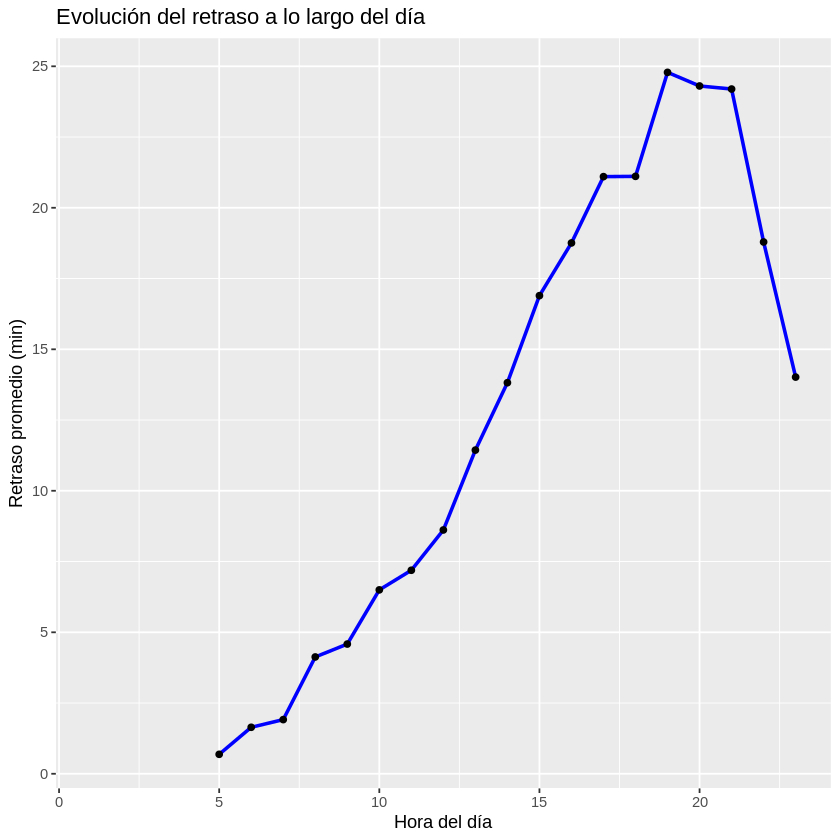

In [ ]:
#3. ¿Cómo varían los retrasos a lo largo del día? Ilustra tu respuesta con un gráfico.
flights |>
  summarize(
  delay_medio = mean(dep_delay, na.rm = TRUE),
  total_vuelos = n(),
  .by = hour
  ) |>
    arrange(hour)

  # Grafico
  flights |>
    summarise(delay_medio = mean(dep_delay, na.rm = TRUE), .by = hour) |>
    ggplot(aes(x = hour, y= delay_medio)) +
    geom_line(color = 'blue', size = 1) +
    geom_point() +
    labs(title = "Evolución del retraso a lo largo del día",
       x = "Hora del día",
       y = "Retraso promedio (min)")

In [ ]:
#4. ¿Qué ocurre si proporcionas un n negativo a slice_min() y amigos?
# Si proporcionas un n negativo, en lugar de elegir las filas con los valores más pequeños (o grandes), slice_min() elimina las filas con los valores más pequeños y te devuelve todo lo demás.
# slice_min(columna, n = -5): "Quita las 5 filas con los valores más bajos y devuélveme todas las filas restantes".
# Es una forma muy limpia de eliminar "outliers" o valores extremos. Por ejemplo, si quieres analizar el retraso de los vuelos pero quieres descartar los vuelos que salieron extremadamente temprano (los que tienen el récord de puntualidad), podrías usar slice_min(dep_delay, n = -10).

In [ ]:
#5. Explica lo que count() hace en términos de los verbos dplyr que acabas de aprender ¿Qué hace el argumento sort a count() hace?
# En términos de los verbos de dplyr que hemos visto, count() es la combinación exacta de group_by() + summarise().
flights |> count(dest)

# Hace exactamente lo mismo que esto
#flights |>
#  group_by(dest) |>
#  summarise(n = n()) |>
#  ungroup()

#¿Qué hace el argumento sort?
#Por defecto, count() te devuelve la lista en el orden en que aparecen los grupos en tus datos o por orden alfabético.

#El argumento sort = TRUE añade un paso extra de arrange() al final, ordenando los resultados de mayor a menor según la columna n.
flights |> count(carrier, sort = TRUE)

# Hace lo mismo que esto:
#flights |>
#  group_by(carrier) |>
#  summarise(n = n()) |>
#  arrange(desc(n))

dest,n
<chr>,<int>
ABQ,254
ACK,265
ALB,439
ANC,8
ATL,17215
AUS,2439
AVL,275
BDL,443
BGR,375


carrier,n
<chr>,<int>
UA,58665
B6,54635
EV,54173
DL,48110
AA,32729
MQ,26397
US,20536
9E,18460
WN,12275


In [ ]:
#6. Supongamos que tenemos el siguiente marco de datos minúsculo:
df <- tibble(
  x = 1:5,
  y = c('a','b','a','a','b'),
  z = c('K','K','L','L','K')
)

In [ ]:
#1. Escribe cómo crees que será la salida; luego comprueba si has acertado y describe lo que group_by() hace.
df
# Creo que agrupará los valores en base a y, pero no será visible.
df |>
  group_by(y)

x,y,z
<int>,<chr>,<chr>
1,a,K
2,b,K
3,a,L
4,a,L
5,b,K


x,y,z
<int>,<chr>,<chr>
1,a,K
2,b,K
3,a,L
4,a,L
5,b,K


In [ ]:
#2. Escribe como crees que será la salida; luego comprueba si has acertado y describe lo que arrange() hace. Comenta también en qué se diferencia del group_by() de la parte (a)
df |>
  arrange(y)
# Pienso que ordenará los datos de la columna y, ordenando las a y las b
df

x,y,z
<int>,<chr>,<chr>
1,a,K
3,a,L
4,a,L
2,b,K
5,b,K


x,y,z
<int>,<chr>,<chr>
1,a,K
2,b,K
3,a,L
4,a,L
5,b,K


In [ ]:
#3. Escribe cómo crees que será la salida; luego comprueba si has acertado y describe lo que hace la tubería
df |>
  group_by(y) |>
  summarize(mean_x = mean(x))
# Agrupará los valores en torno a la columna y. Hará un promedio de los valores, separados por a y b

y,mean_x
<chr>,<dbl>
a,2.666667
b,3.500000


In [ ]:
#4. Escribe cómo crees que será la salida; luego comprueba si hs acertado y describe lo que hace la tubería. Después, comenta lo que dice el mensaje.
df |>
  group_by(y, z) |>
  summarize(mean_x = mean(x))
# Selecciona las columnas y y z para luego hacer un promedio de los valores int tanto de a y b, y K y L

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by y and z.
ℹ Output is grouped by y.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(y, z))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


y,z,mean_x
<chr>,<chr>,<dbl>
a,K,1.0
a,L,3.5
b,K,3.5


In [ ]:
#5. Escribe cómo crees que será la salida; luego comprueba si has acertado y describe lo que hace la tubería. ¿En qué se diferencia la salida de la de la parte (d)?
df |>
  group_by(y,z) |>
  summarize(mean_x = mean(x), .groups = 'drop')
# Lo que hace el código es seleccionar columnas y y z para calcular el promedio asociado a sus respectivas variables. Luego los desagrupa.
# Al no usar el drop, si después de esto intentas hacer otra operación, R seguirá pensando que los datos están divididos por y, lo que puede darte resultados inesperados si querías trabajar con la tabla completa.
# Si usamos el drop: Aquí tú tienes el control total. Le estás diciendo a R: "Una vez que termines de calcular el promedio, olvídate de todos los grupos".

y,z,mean_x
<chr>,<chr>,<dbl>
a,K,1.0
a,L,3.5
b,K,3.5


In [ ]:
#6. Escribe cómo crees que serán las salidas; luego comprueba si has acertado y describe lo que hace cada tubería. ¿En qué se diferencian las salidas de las dos tuberías?
df |>
  group_by(y, z) |>
  summarize(mean_x = mean(x))
# agrupa los datos en base a las columnas y y z, luego calcula el promedio de x segun cada variable agrupada de las columnas y y z. La columna x no se muestra. Summarize colapasa la tabla
df |>
  group_by(y, z) |>
  mutate(mean_x = mean(x))
# Lo que sucederá acá es que se agruparan los datos tomando en cuenta las columnas y y z, luego se creará una nueva columna tomando la media de x y distibuyendolas en las columnas y y z. La columna x se muestra. Hay valores duplicados. Mutate expande la tabla,

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by y and z.
ℹ Output is grouped by y.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(y, z))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


y,z,mean_x
<chr>,<chr>,<dbl>
a,K,1.0
a,L,3.5
b,K,3.5


x,y,z,mean_x
<int>,<chr>,<chr>,<dbl>
1,a,K,1.0
2,b,K,3.5
3,a,L,3.5
4,a,L,3.5
5,b,K,3.5


## Caso práctico: Agregados y tamaño de la muestra.

In [3]:
# Siempre que hagas cualquier agregación, es buena idea incluir un recuento (n()). Así te aseguras de que no estás sacando conclusiones basadas en cantidades muy pequeñas de datos. Lo demostraremos con algunos datos de béisbol del paquete Lahman. En concreto, compararemos la proporción de veces que un jugador consigue un hit(H) frente al número de veces que intenta poner la pelota en juego(AB)
install.packages('Lahman')
library(Lahman)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
?Batting

In [ ]:
glimpse(Batting)

Rows: 128,598
Columns: 22
$ playerID <chr> "aardsda01", "aardsda01", "aardsda01", "aardsda01", "aardsda0…
$ yearID   <int> 2004, 2006, 2007, 2008, 2009, 2010, 2012, 2013, 2015, 1954, 1…
$ stint    <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ teamID   <fct> SFN, CHN, CHA, BOS, SEA, SEA, NYA, NYN, ATL, ML1, ML1, ML1, M…
$ lgID     <fct> NL, NL, AL, AL, AL, AL, AL, NL, NL, NL, NL, NL, NL, NL, NL, N…
$ G        <int> 11, 45, 25, 47, 73, 53, 1, 43, 33, 122, 153, 153, 151, 153, 1…
$ AB       <int> 0, 2, 0, 1, 0, 0, 0, 0, 1, 468, 602, 609, 615, 601, 629, 590,…
$ R        <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 58, 105, 106, 118, 109, 116, 102, …
$ H        <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 131, 189, 200, 198, 196, 223, 172,…
$ X2B      <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 27, 37, 34, 27, 34, 46, 20, 39, 28…
$ X3B      <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 9, 14, 6, 4, 7, 11, 10, 6, 4, 2…
$ HR       <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 13, 27, 26, 44, 30, 39, 40, 34, 45…
$ RBI      <in

In [6]:
batters <- Lahman::Batting |>
  group_by(playerID) |>
  summarize(
  performance = sum(H, na.rm = TRUE) / sum(AB, na.rm = TRUE),
  n = sum(AB, na.rm = TRUE)
  )
batters

playerID,performance,n
<chr>,<dbl>,<int>
aardsda01,0.00000000,4
aaronha01,0.30499838,12364
aaronto01,0.22881356,944
aasedo01,0.00000000,5
abadan01,0.09523810,21
abadfe01,0.11111111,9
abadijo01,0.22448980,49
abbated01,0.25361367,3044
abbeybe01,0.16888889,225


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


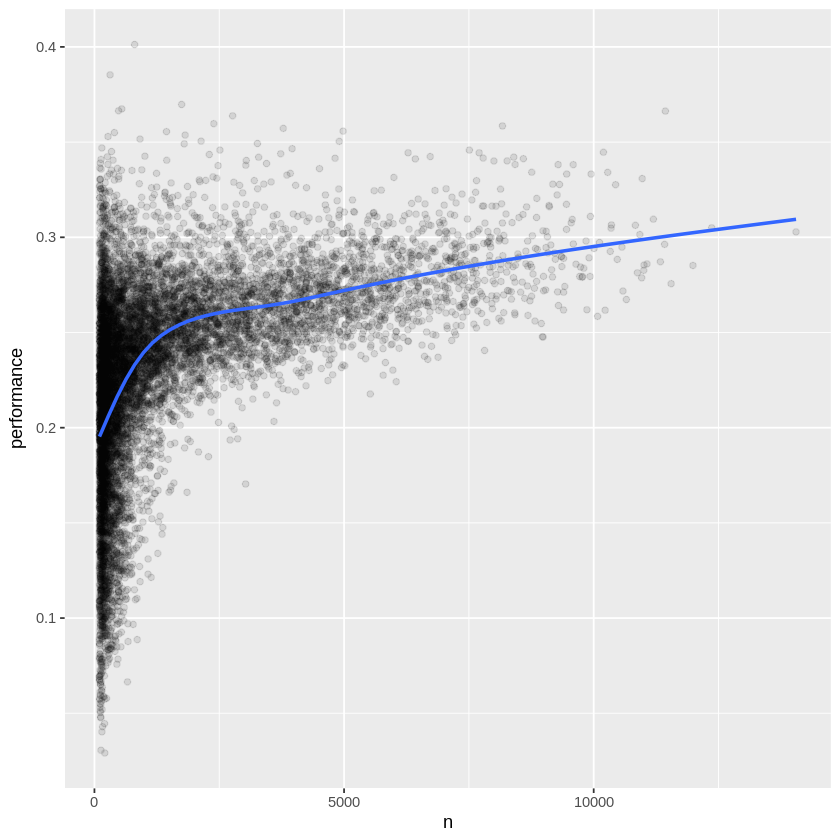

In [7]:
# Si comparamos la habilidad del bateador (medida por la media de bateo, performance) con el número de oportunidades de golpear la pelota (n), observamos dos patrones:
# La variación en performance es mayor entre los jugadores con menos bateos. La forma de este gráfico es muy característica: siempre que representes una media frente al tamaño del grupo, verás que la variación disminuye a medida que aumenta el tamaño de la muestra.
# Existe una correlación positiva entre la habilidad (performance) y las oportunidades de golpear la bola (n) porque los equipos quieren dar a sus mejores bateadores el mayor número de oportunidades de golpear la bola.

batters |>
  filter(n > 100) |>
  ggplot(aes(x = n, y = performance)) +
  geom_point(alpha = 1 / 10) +
  geom_smooth(se = FALSE)

La ley de los grandes números es un principio fundamental de la probabilidad que establece que, al repetir un experimento aleatorio numerosas veces, el promedio de los resultados obtenidos se acerca cada vez más al valor esperado (o promedio teórico).

¿Cómo funciona?
- A corto plazo: Pueden ocurrir fluctuaciones extremas y los resultados pueden parecer irregulares.
- A largo plazo: A medida que el número de repeticiones crece, el azar se estabiliza y las variaciones se equilibran, revelando la verdadera probabilidad matemática.

## Resumen

En este capítulo, hemos aprendido las herramientas que dplyr proporciona para trabajar con marcos de datos. A grandes rasgos, las herramientas se agrupan en tres categorías: las que manipulan filas (como filter() y arrange()), as que manipulan columnas(cómo select() y mutate()) y las que manipulan grupos (como group_by() y summarize())